# LIGHTGBM ANALISIS SHAP

**Objetivo:** Analizar la explicabilidad del modelo CatBoost mediante SHAP values.

Este notebook se puede ejecutar MÚLTIPLES VECES (no re-entrena, solo carga el modelo guardado), tiene como pre-requisito la ejecución de modelo en el cuaderno '5_modelado_LightGBMFinal.ipynb'

Análisis incluidos:
1. Summary Plot (Importancia global)
2. Beeswarm Plot (Dirección del impacto)
3. Dependence Plots (Top variables)
4. Waterfall Plots (Explicación individual)
5. Comparación SHAP entre fases T0, T1, T2

## 0. Librerias y configuración

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import lightgbm as lgb
import joblib
warnings.filterwarnings('ignore')

from lightgbm import LGBMClassifier
import shap
shap.initjs()

plt.style.use('seaborn-v0_8-whitegrid')

# Directorios
INPUT_DIR_MODELS = "../outputs/models/LightGBM/"
OUTPUT_DIR_SHAP = "../outputs/figures/modelado/LightGBM/SHAP/"
os.makedirs(OUTPUT_DIR_SHAP, exist_ok=True)

## 1. Cargar modelos y datos (sin re-entrenar)

In [4]:
# Cargar modelos y datos para las 3 fases
modelos = {}
datos = {}
preprocessors = {}

for fase in ['T0', 'T1', 'T2']:
    # Cargar modelo
    modelos[fase] = lgb.Booster(model_file=f'{INPUT_DIR_MODELS}lightgbm_final_{fase}.txt')
    
    # Cargar datos de evaluación
    datos[fase] = joblib.load(f'{INPUT_DIR_MODELS}datos_evaluacion_{fase}.joblib')
    
    # Cargar preprocessors
    preprocessors[fase] = joblib.load(f'{INPUT_DIR_MODELS}preprocessors_{fase}.joblib')
    
    print(f"Fase {fase} cargada")

print(f"\nModelos: {list(modelos.keys())}")
print(f"Datos: {list(datos.keys())}")
print("\nModelos y datos cargados sin re-entrenar")

Fase T0 cargada
Fase T1 cargada
Fase T2 cargada

Modelos: ['T0', 'T1', 'T2']
Datos: ['T0', 'T1', 'T2']

Modelos y datos cargados sin re-entrenar


## 2 Funciones para análisis SHAP

In [5]:
def grafica_impactoShap_vars(fase, modelos, datos, preprocessors,output_dir):
    #Genera gráfico SHAP summary (beeswarm) para la fase indicada.
    
    # Obtiene datos
    X_test_prep = datos[fase]['X_test_prep']
    feature_names = preprocessors[fase]['feature_names']
    
    # Crea explainer
    explainer = shap.TreeExplainer(modelos[fase])
    shap_values = explainer.shap_values(X_test_prep)
    
    # Si clasificación binaria → tomar clase positiva
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    # Grafica valores SHAP
    shap.summary_plot(
        shap_values, 
        X_test_prep,
        show=False, 
        feature_names=feature_names
    )

    plt.title(f"Importancia global de variables (SHAP) -  Fase {fase}", fontsize=16)
    plt.tight_layout()
    filepath = f'{output_dir}impactoShap_{fase}.png'
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()

    return shap_values

def grafica_importancia_vars(fase, shap_values, datos, preprocessors, output_dir):
    
    X_test_prep = datos[fase]['X_test_prep']
    feature_names = preprocessors[fase]['feature_names']
    
    plt.figure(figsize=(10, 8))
    
    shap.summary_plot(
        shap_values,
        X_test_prep,
        feature_names=feature_names,
        plot_type="bar",
        max_display=20,
        show=False
    )
    
    

    plt.title(f'Importancia de variables (SHAP) - Fase {fase}', fontsize=14)
    plt.tight_layout()
    
    filepath = f'{output_dir}shap_importance_bar_{fase}.png'
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Guardado: {filepath}")



def calcular_importancia_shap(fase,shap_values,datos,output_dir,top_n=10):
    # Si es clasificación binaria (lista de clases)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    feature_importance = pd.DataFrame({
        'feature': datos[fase]['feature_names'],
        'importance': np.abs(shap_values).mean(axis=0)
    }).sort_values('importance', ascending=False)

    # Impresión en consola
    print("================================================================================")
    print(f"  TOP {top_n} VARIABLES MÁS IMPORTANTES (SHAP) - Fase {fase}")
    print("================================================================================")
    print(f"\n{'Rank':<6} {'Variable':<45} {'Importancia':>12}")
    print("--------------------------------------------------------------------------------")

    for i, (_, row) in enumerate(feature_importance.head(top_n).iterrows(), 1):
        print(f"{i:<6} {row['feature']:<45} {row['importance']:>12.4f}")

    # Guardar CSV
    filepath = f"{output_dir}feature_importance_{fase}.csv"
    feature_importance.to_csv(filepath, index=False)

    print(f"\nGuardado: {filepath}")

    return feature_importance


def grafica_dependencia_shap_top(
    fase,
    shap_values,
    feature_importance,
    datos,
    output_dir,
    top_n=4
):
    #Genera gráficos de dependencia SHAP para las top N variables.

    
    # Seleccionar top variables
    top_features = feature_importance.head(top_n)['feature'].tolist()
    
    X_test_prep = datos[fase]['X_test_prep']
    feature_names = datos[fase]['feature_names']
    
    # Determinar layout dinámico (2x2 si top_n=4, etc.)
    n_cols = 2
    n_rows = (top_n + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = axes.flatten()
    
    for ax, feature in zip(axes, top_features):
        feature_idx = feature_names.index(feature)
        
        shap.dependence_plot(
            feature_idx,
            shap_values,
            X_test_prep,
            ax=ax,
            show=False
        )
        
        ax.set_title(feature)
    
    # Si sobran ejes (cuando top_n es impar)
    for ax in axes[len(top_features):]:
        ax.remove()
    
    plt.suptitle(
        f'Gráficos de Dependencia SHAP - Top {top_n} Variables - Fase {fase})',
        fontsize=14,
        y=1.02
    )
    
    plt.tight_layout()
    
    filepath = f'{output_dir}shap_dependence_top{top_n}_{fase}.png'
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Guardado: {filepath}")


## 3 Análisis SHAP

## 3.1 Fase T0

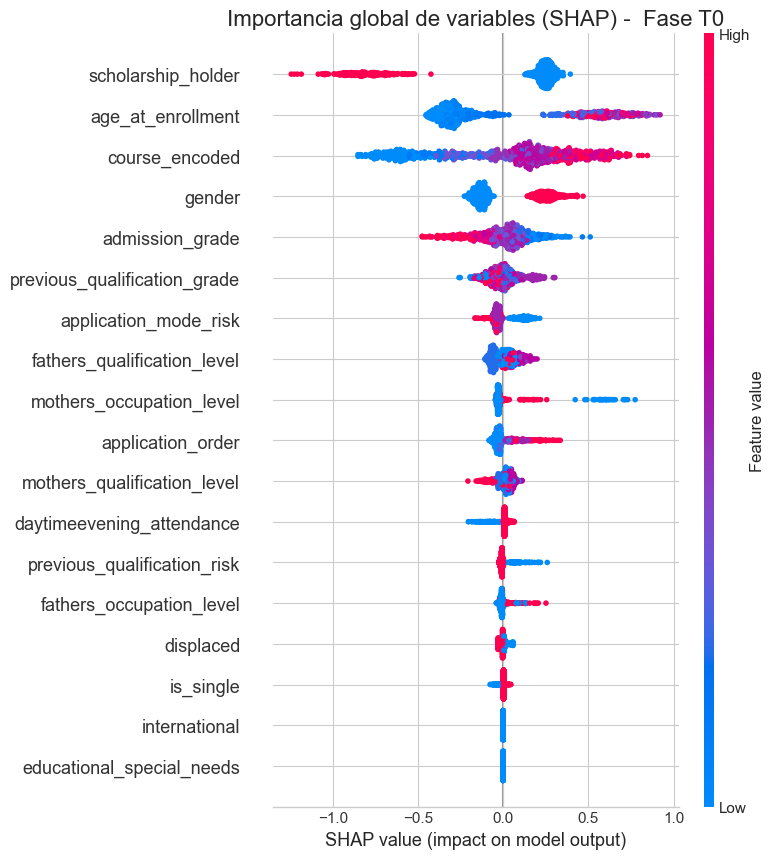

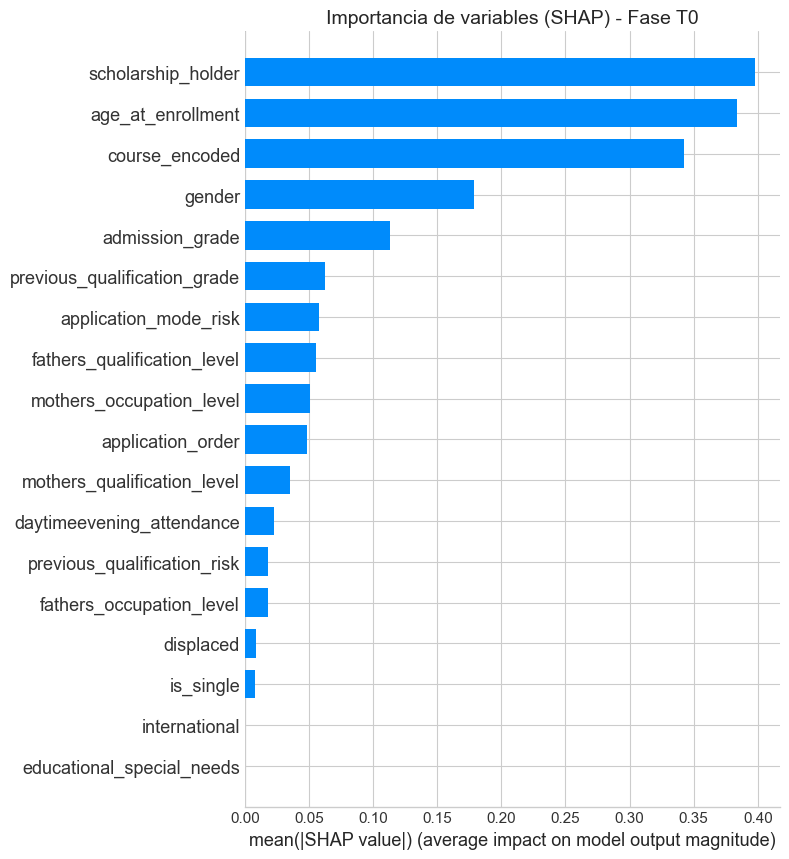

Guardado: ../outputs/figures/modelado/LightGBM/SHAP/shap_importance_bar_T0.png
  TOP 10 VARIABLES MÁS IMPORTANTES (SHAP) - Fase T0

Rank   Variable                                       Importancia
--------------------------------------------------------------------------------
1      scholarship_holder                                  0.3974
2      age_at_enrollment                                   0.3838
3      course_encoded                                      0.3425
4      gender                                              0.1784
5      admission_grade                                     0.1131
6      previous_qualification_grade                        0.0622
7      application_mode_risk                               0.0578
8      fathers_qualification_level                         0.0554
9      mothers_occupation_level                            0.0504
10     application_order                                   0.0481

Guardado: ../outputs/figures/modelado/LightGBM/SHAP/feature_

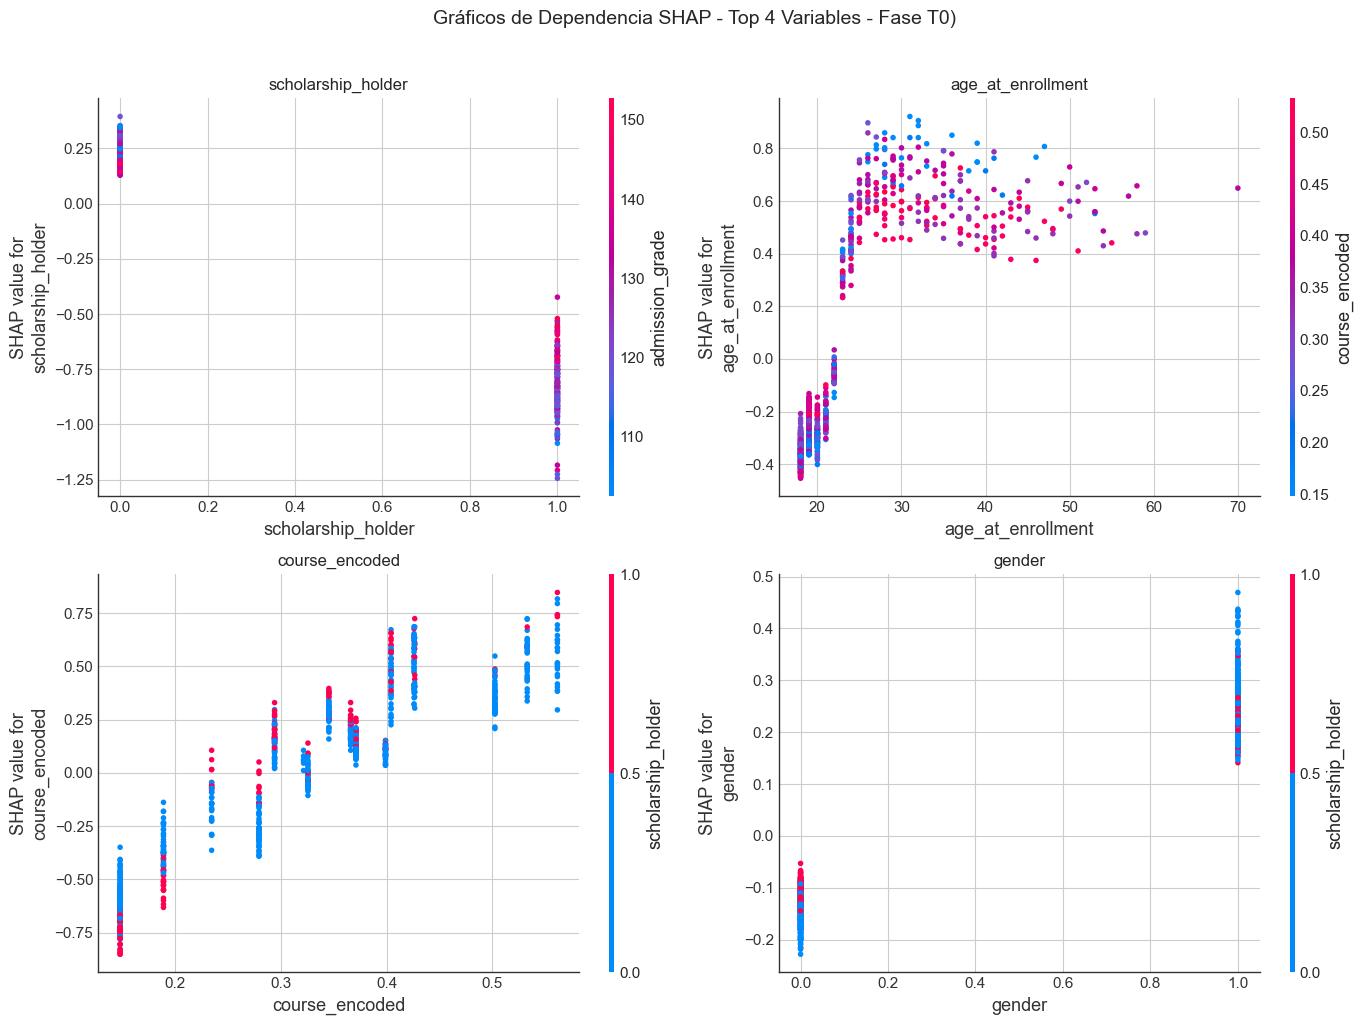

Guardado: ../outputs/figures/modelado/LightGBM/SHAP/shap_dependence_top4_T0.png


In [6]:
shap_values= grafica_impactoShap_vars('T0', modelos, datos, preprocessors, OUTPUT_DIR_SHAP)
grafica_importancia_vars('T0', shap_values, datos, preprocessors, OUTPUT_DIR_SHAP)
fi_T0 = calcular_importancia_shap(fase='T0',shap_values=shap_values,datos=datos, output_dir=OUTPUT_DIR_SHAP, top_n=10)
grafica_dependencia_shap_top(
		fase='T0',
		shap_values=shap_values,
		feature_importance=fi_T0,
		datos=datos,
		output_dir=OUTPUT_DIR_SHAP,
		top_n=4
)

## 3.2 Fase T1

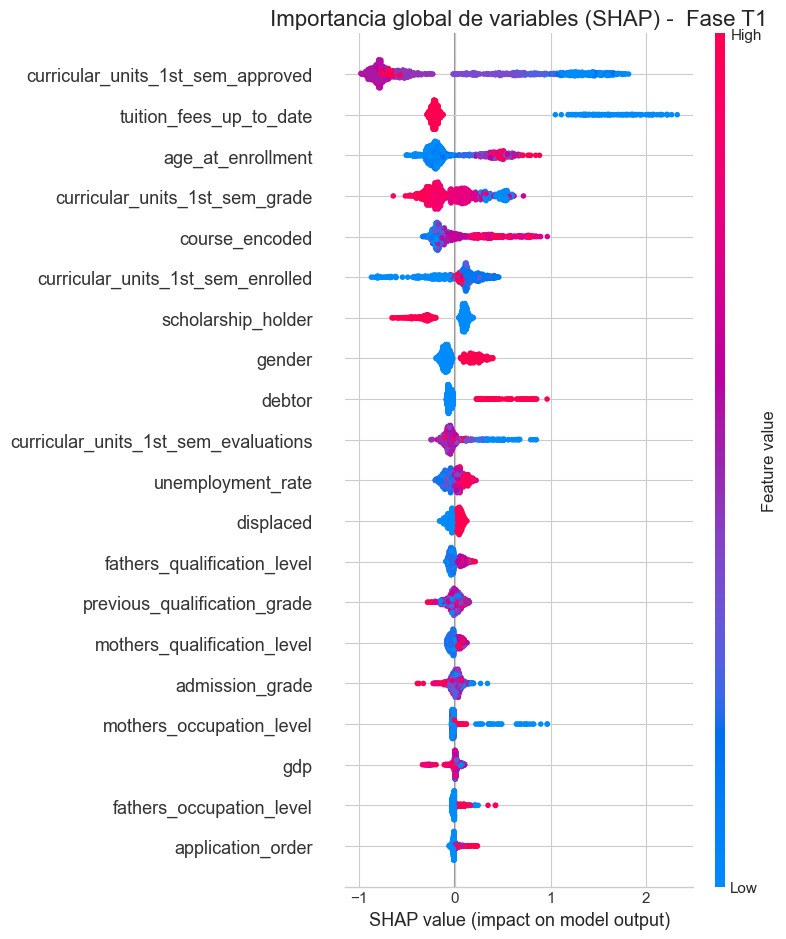

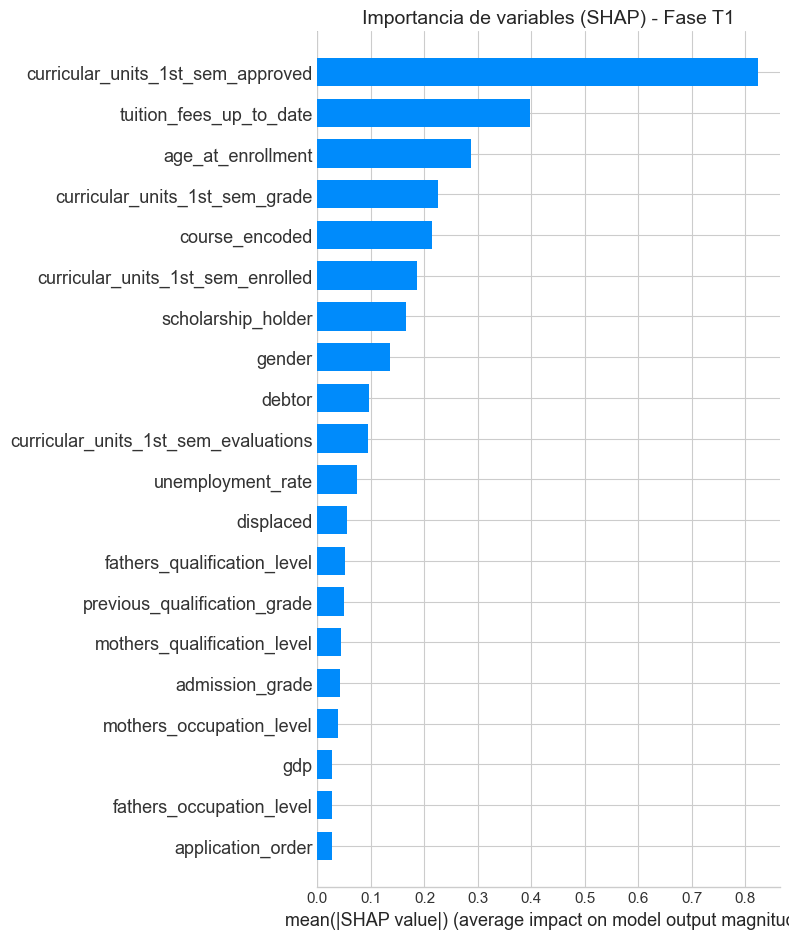

Guardado: ../outputs/figures/modelado/LightGBM/SHAP/shap_importance_bar_T1.png
  TOP 10 VARIABLES MÁS IMPORTANTES (SHAP) - Fase T1

Rank   Variable                                       Importancia
--------------------------------------------------------------------------------
1      curricular_units_1st_sem_approved                   0.8236
2      tuition_fees_up_to_date                             0.3980
3      age_at_enrollment                                   0.2866
4      curricular_units_1st_sem_grade                      0.2252
5      course_encoded                                      0.2144
6      curricular_units_1st_sem_enrolled                   0.1860
7      scholarship_holder                                  0.1649
8      gender                                              0.1349
9      debtor                                              0.0959
10     curricular_units_1st_sem_evaluations                0.0942

Guardado: ../outputs/figures/modelado/LightGBM/SHAP/feature_

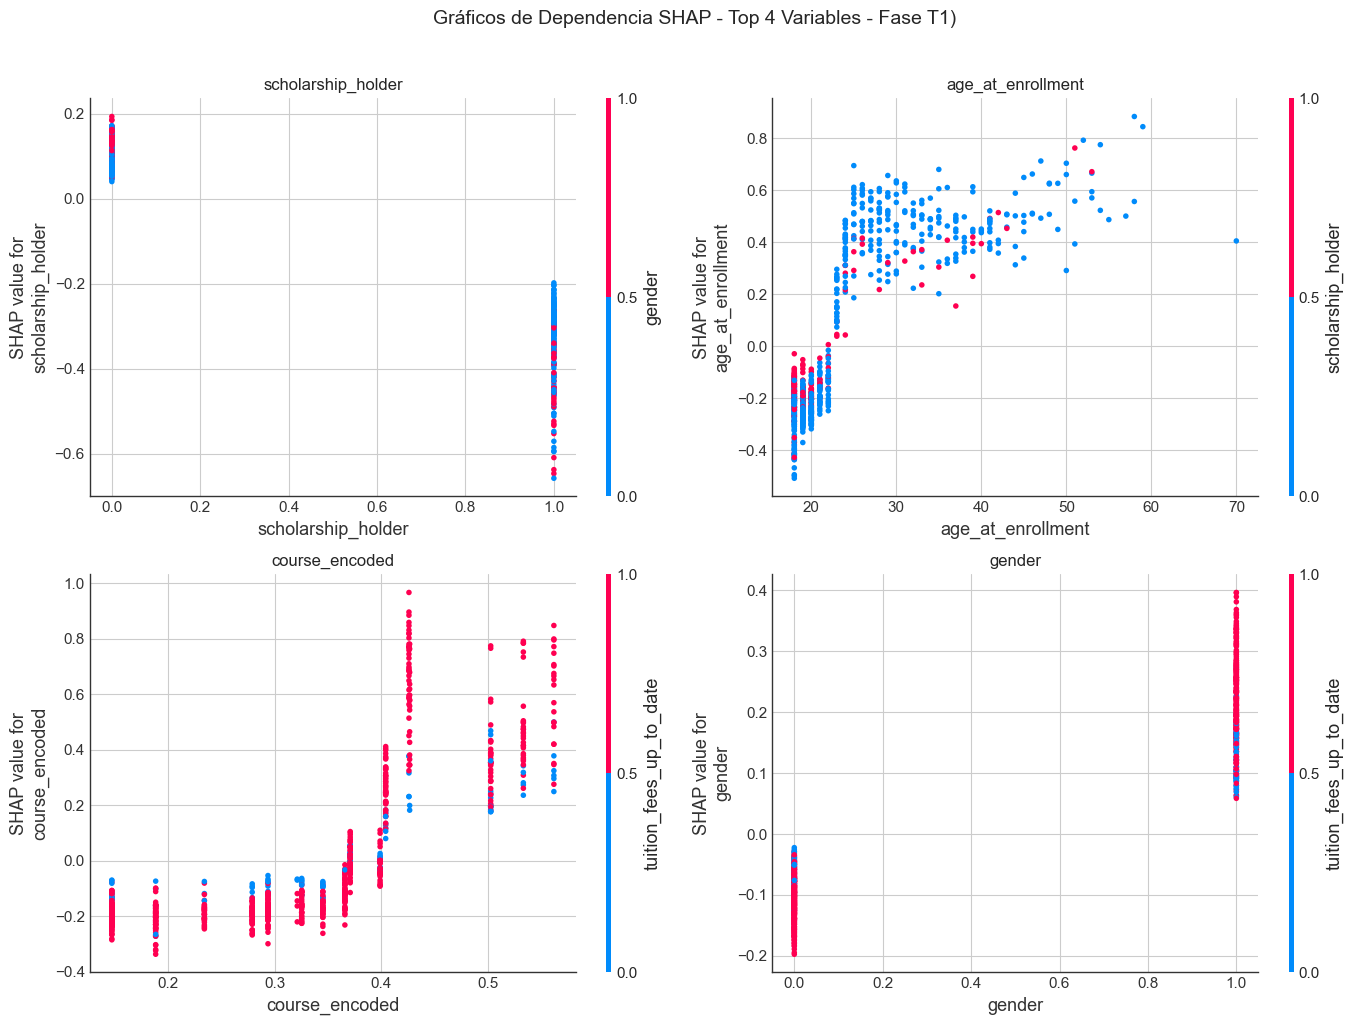

Guardado: ../outputs/figures/modelado/LightGBM/SHAP/shap_dependence_top4_T1.png


In [7]:
shap_values = grafica_impactoShap_vars('T1', modelos, datos, preprocessors, OUTPUT_DIR_SHAP)
grafica_importancia_vars('T1', shap_values, datos, preprocessors, OUTPUT_DIR_SHAP)
fi_T1 = calcular_importancia_shap(fase='T1',shap_values=shap_values,datos=datos, output_dir=OUTPUT_DIR_SHAP, top_n=10)
grafica_dependencia_shap_top(
		fase='T1',
		shap_values=shap_values,
		feature_importance=fi_T0,
		datos=datos,
		output_dir=OUTPUT_DIR_SHAP,
		top_n=4
)

## 3.3 Fase T2

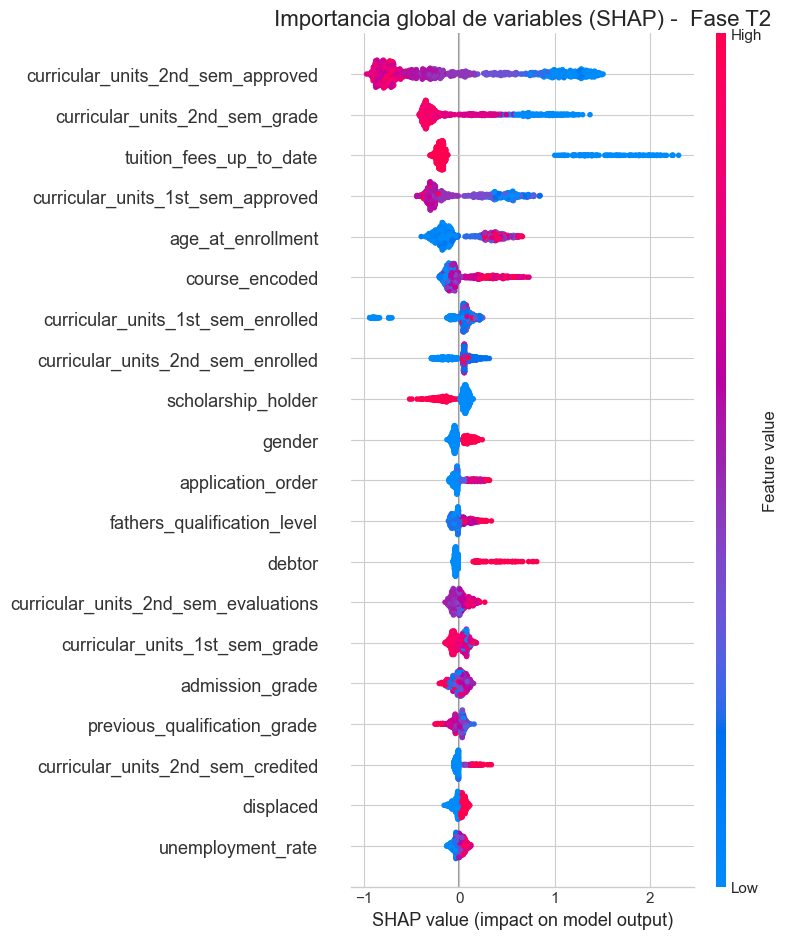

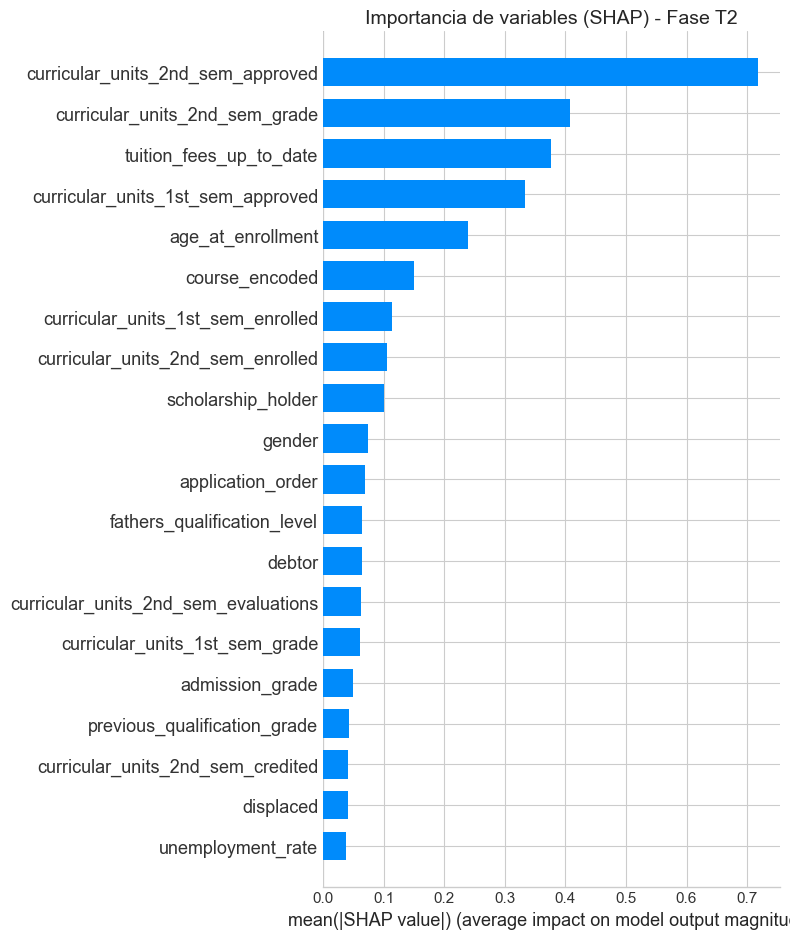

Guardado: ../outputs/figures/modelado/LightGBM/SHAP/shap_importance_bar_T2.png
  TOP 10 VARIABLES MÁS IMPORTANTES (SHAP) - Fase T2

Rank   Variable                                       Importancia
--------------------------------------------------------------------------------
1      curricular_units_2nd_sem_approved                   0.7184
2      curricular_units_2nd_sem_grade                      0.4070
3      tuition_fees_up_to_date                             0.3769
4      curricular_units_1st_sem_approved                   0.3337
5      age_at_enrollment                                   0.2387
6      course_encoded                                      0.1498
7      curricular_units_1st_sem_enrolled                   0.1133
8      curricular_units_2nd_sem_enrolled                   0.1051
9      scholarship_holder                                  0.0999
10     gender                                              0.0746

Guardado: ../outputs/figures/modelado/LightGBM/SHAP/feature_

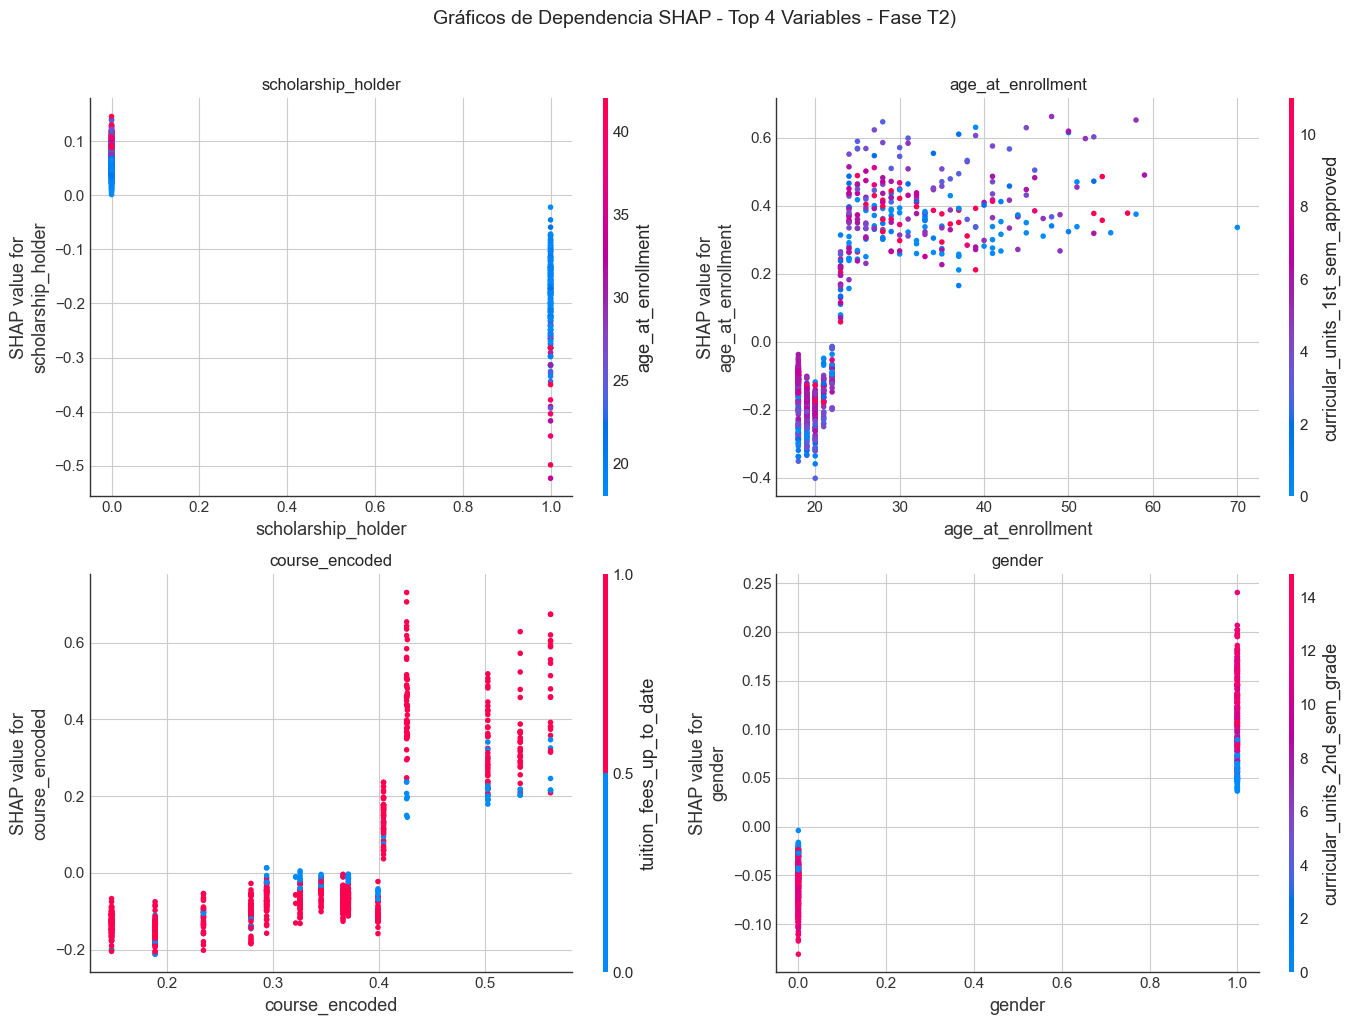

Guardado: ../outputs/figures/modelado/LightGBM/SHAP/shap_dependence_top4_T2.png


In [8]:
shap_values = grafica_impactoShap_vars('T2', modelos, datos, preprocessors,OUTPUT_DIR_SHAP)
grafica_importancia_vars('T2', shap_values, datos, preprocessors, OUTPUT_DIR_SHAP)
fi_T2 = calcular_importancia_shap(fase='T2',shap_values=shap_values,datos=datos, output_dir=OUTPUT_DIR_SHAP, top_n=10)
grafica_dependencia_shap_top(
		fase='T2',
		shap_values=shap_values,
		feature_importance=fi_T0,
		datos=datos,
		output_dir=OUTPUT_DIR_SHAP,
		top_n=4
)

In [9]:
print("Calculando SHAP values para T0 y T2...")

# T0
explainer_T0 = shap.TreeExplainer(modelos['T0'])
shap_values_T0 = explainer_T0.shap_values(datos['T0']['X_test_prep'])
if isinstance(shap_values_T0, list):
    shap_values_T0 = shap_values_T0[1]

# T1
explainer_T1 = shap.TreeExplainer(modelos['T1'])
shap_values_T1 = explainer_T1.shap_values(datos['T1']['X_test_prep'])
if isinstance(shap_values_T1, list):
    shap_values_T1 = shap_values_T1[1]

# T2
explainer_T2 = shap.TreeExplainer(modelos['T2'])
shap_values_T2 = explainer_T2.shap_values(datos['T2']['X_test_prep'])
if isinstance(shap_values_T2, list):
    shap_values_T2 = shap_values_T2[1]

print("✓ SHAP calculado para las 3 fases")

Calculando SHAP values para T0 y T2...
✓ SHAP calculado para las 3 fases


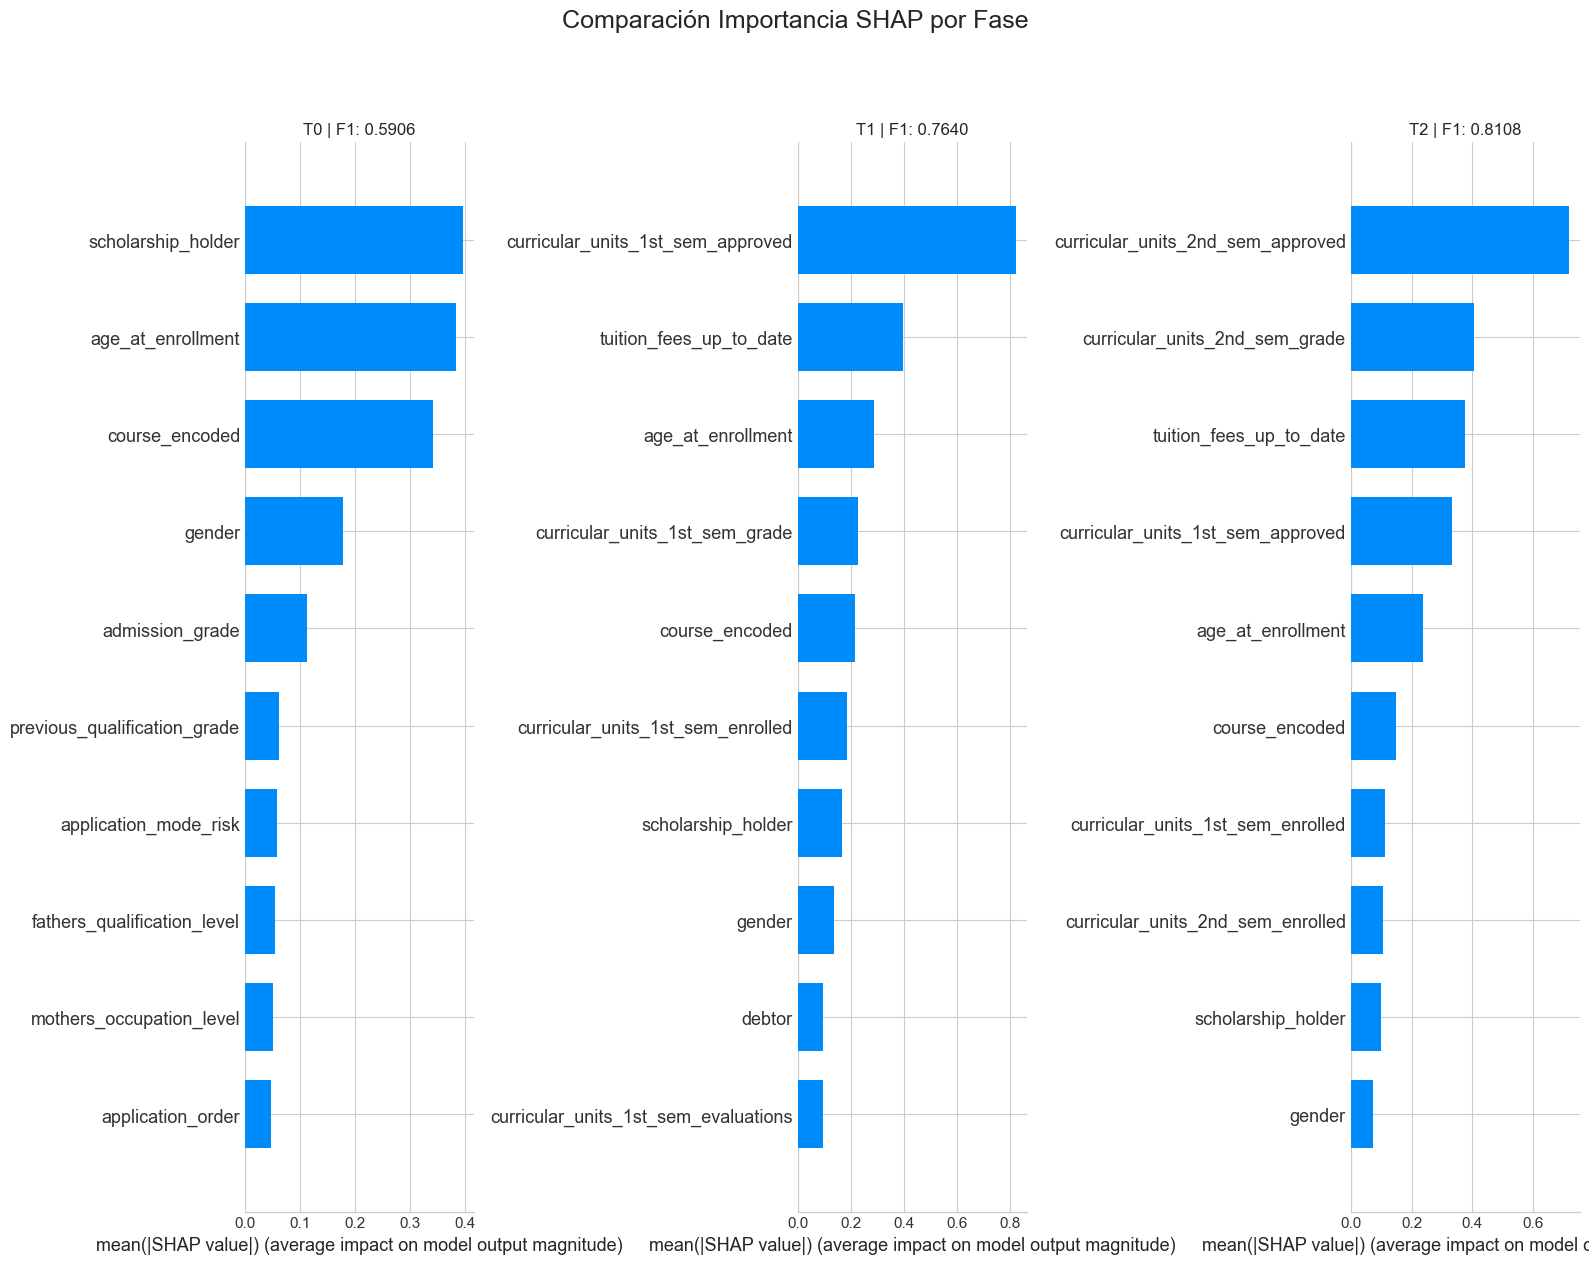

In [10]:
# Summary plots comparativos

fig, axes = plt.subplots(1, 3, figsize=(24, 8))  # Aumentamos tamaño general

all_data = [
    ('T0', shap_values_T0, datos['T0']),
    ('T1', shap_values_T1, datos['T1']),
    ('T2', shap_values_T2, datos['T2'])
]

for ax, (fase, shap_vals, data) in zip(axes, all_data):
    plt.sca(ax)
    
    shap.summary_plot(
        shap_vals,
        data['X_test_prep'],
        plot_type="bar",
        max_display=10,
        show=False,
        plot_size=(16,12)  
    )
    
    ax.set_title(f"{fase} | F1: {data['metricas_test']['f1']:.4f}", fontsize=12)

plt.suptitle('Comparación Importancia SHAP por Fase', fontsize=18, y=1.05)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR_SHAP}shap_comparison_phases.png', dpi=200, bbox_inches='tight')
plt.show()

Total desertores correctamente predichos: 212
Estudiante #33
  • Real: Desertor
  • Predicción: Desertor
  • Probabilidad: 0.8622


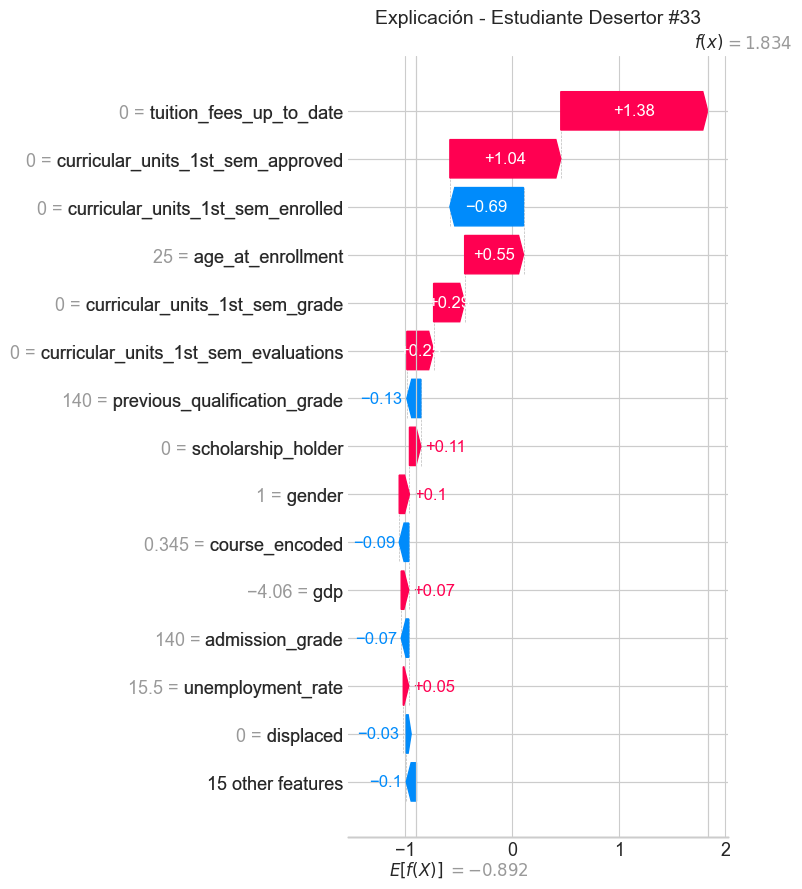

In [11]:
# Encontrar un desertor predicho correctamente
y_test = datos['T1']['y_test']
y_pred = datos['T1']['y_test_pred']
y_proba = datos['T1']['y_test_proba']

# Obtiene todos los desertores predichos correctamente
idx_desertores = np.where((y_test.values == 1) & (y_pred == 1))[0]
print(f"Total desertores correctamente predichos: {len(idx_desertores)}")

posicion = 10  # Cambiar este valor para seleccionar otro estudiante
idx_desertor = idx_desertores[posicion]

print(f"Estudiante #{idx_desertor}")
print(f"  • Real: Desertor")
print(f"  • Predicción: Desertor")
print(f"  • Probabilidad: {y_proba[idx_desertor]:.4f}")

# SHAP Explanation
expected_value = explainer_T1.expected_value
if isinstance(expected_value, list):
    expected_value = expected_value[1]

shap_exp = shap.Explanation(
    values=shap_values_T1[idx_desertor],
    base_values=expected_value,
    data=datos['T1']['X_test_prep'].iloc[idx_desertor].values,
    feature_names=datos['T1']['feature_names']
)

plt.figure(figsize=(12, 8))
shap.waterfall_plot(shap_exp, max_display=15, show=False)
plt.title(f'Explicación - Estudiante Desertor #{idx_desertor}', fontsize=14)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR_SHAP}shap_waterfall_desertor_T1.png', dpi=150, bbox_inches='tight')
plt.show()